<a href="https://colab.research.google.com/github/elio12162030/IS484-Practica001-Jueves-Huaman/blob/main/Ejercicio3_Inspeccion_Aquino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 3: Inspección visual de un producto

**Estudiante:** Elio Huaman Aquino  
**Curso:** Inteligencia Artificial I (IS-484)

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Matriz NumPy de 5×5, donde 0 representa un píxel normal y 1 un píxel defectuoso. |
| **Acciones (A)** | Aprobar el producto, enviarlo a revisión manual o rechazarlo. |
| **Entorno (E)** | Línea de producción, cámara, productos, iluminación y estación de control de calidad. |
| **Objetivo** | Evitar que productos defectuosos continúen en la línea sin rechazar innecesariamente productos aceptables. |
| **Medida de desempeño (P)** | Porcentaje de defectos detectados, baja tasa de falsos rechazos, rapidez de inspección y menor costo de control. |

### Justificación de las reglas

Un producto sin píxeles defectuosos se aprueba porque no presenta evidencia visual de falla. Entre 1 y 3 defectos se solicita revisión manual, ya que podrían ser daños menores o ruido de captura. Con más de 3 defectos se rechaza porque la concentración de anomalías supera el nivel tolerable. Los umbrales equilibran la calidad del producto y el costo de una inspección humana.

### Código

In [ ]:
import numpy as np

def agente_inspeccion(imagen):
    # Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso).
    # Retorna una tupla (acción, motivo).
    if not isinstance(imagen, np.ndarray) or imagen.shape != (5, 5):
        return "dato inválido", "la imagen debe ser una matriz NumPy de 5x5"
    if not np.all(np.isin(imagen, [0, 1])):
        return "dato inválido", "la matriz solo puede contener valores 0 y 1"

    defectos = int(np.count_nonzero(imagen == 1))

    if defectos == 0:
        return "aprobar", "no se detectaron píxeles defectuosos"
    if defectos <= 3:
        return "revisión manual", f"se detectaron {defectos} píxeles defectuosos"
    return "rechazar", f"se detectaron {defectos} píxeles defectuosos, más del límite permitido"

### Simulación y pruebas

0 defectos                   -> aprobar: no se detectaron píxeles defectuosos
1 defecto                    -> revisión manual: se detectaron 1 píxeles defectuosos
3 defectos (borde revisión)  -> revisión manual: se detectaron 3 píxeles defectuosos
4 defectos (borde rechazo)   -> rechazar: se detectaron 4 píxeles defectuosos, más del límite permitido


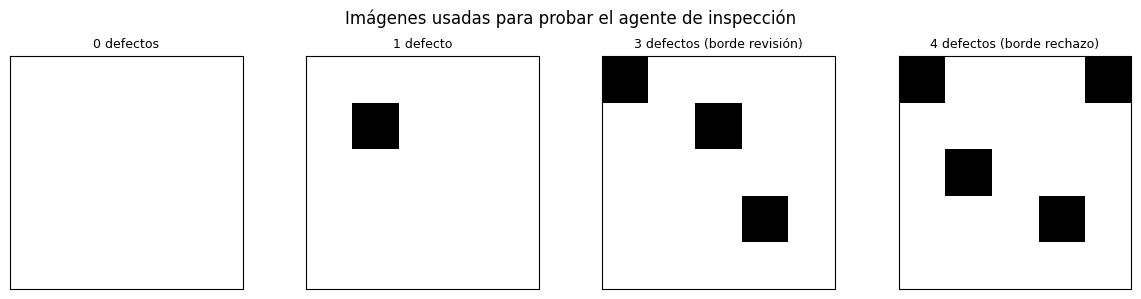

In [ ]:
import matplotlib.pyplot as plt

imagenes_prueba = {
    "0 defectos": np.zeros((5, 5), dtype=int),
    "1 defecto": np.array([
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ]),
    "3 defectos (borde revisión)": np.array([
        [1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
    ]),
    "4 defectos (borde rechazo)": np.array([
        [1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
    ]),
}

for nombre, imagen in imagenes_prueba.items():
    accion, motivo = agente_inspeccion(imagen)
    print(f"{nombre:<28} -> {accion}: {motivo}")

# Visualización opcional de las cuatro matrices
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (nombre, imagen) in zip(axes, imagenes_prueba.items()):
    ax.imshow(imagen, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(nombre, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Imágenes usadas para probar el agente de inspección")
plt.tight_layout()
plt.show()